# Custom CNN Architecture for Pneumonia Detection
This notebook builds and trains a Convolutional Neural Network (CNN) from scratch to detect pneumonia from chest X-ray images. The goal is to create a lightweight, highly efficient model that prioritizes diagnostic recall (minimizing false negatives).

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
train = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
test = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
val = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

img = tf.keras.utils.img_to_array(tf.keras.utils.load_img('/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/person1001_bacteria_2932.jpeg'))
print(img.shape)


(863, 1244, 3)


In [ ]:
class EarlyStopping(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    model.save('/content/model'+str(epoch)+'.keras')
    if(logs['val_accuracy']>0.85):
      print("\nReached 99% accuracy so cancelling training!")
      self.model.stop_training = True

## Building the Custom Architecture
Designing a custom CNN using 3 Convolutional blocks with Batch Normalization and MaxPooling. Data augmentation (RandomFlip, Rotation, Zoom) is applied directly inside the model, and a Dropout layer (0.5) is used to prevent overfitting.

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.Conv2D(16, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
print(model.summary())
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # Lower LR for stability
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()] # Add Recall to track Pneumonia detection
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,236,833 (12.35 MB)

 Trainable params: 3,236,097 (12.34 MB)

 Non-trainable params: 736 (2.88 KB)

None


## Data Loading & Preprocessing
Loading the dataset from the directory, applying binary classification labels, and optimizing the data pipeline with caching and prefetching for faster training.

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(train,
                image_size=(128, 128),
                batch_size=32,
                label_mode = 'binary')

val_dataset = tf.keras.utils.image_dataset_from_directory(val,
                image_size=(128, 128),
                batch_size=32,
                label_mode = 'binary')

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [ ]:
rescale_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (rescale_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (rescale_layer(x), y))

#configure dataset
train_dataset = (train_dataset
                .cache()
                .shuffle(1000)
                .prefetch(buffer_size=tf.data.AUTOTUNE))


val_dataset = (val_dataset
                .cache()
                .shuffle(1000)
                .prefetch(buffer_size=tf.data.AUTOTUNE))


## Model Training
Training the custom model using the Adam optimizer (tuned to a lower learning rate of 1e-4 for stability) and a custom Early Stopping callback to halt training when validation accuracy exceeds our target.

In [ ]:
model.fit(train_dataset, epochs=10, validation_data=val_dataset, verbose= 1, callbacks = [EarlyStopping()])

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 982ms/step - accuracy: 0.8076 - loss: 0.4779 - recall: 0.7805 - val_accuracy: 0.6250 - val_loss: 1.2477 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 159s 977ms/step - accuracy: 0.9321 - loss: 0.2119 - recall: 0.9399 - val_accuracy: 0.6250 - val_loss: 1.3607 - val_recall: 1.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 198s 952ms/step - accuracy: 0.9456 - loss: 0.1499 - recall: 0.9563 - val_accuracy: 0.6731 - val_loss: 0.7476 - val_recall: 0.9974
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 199s 932ms/step - accuracy: 0.9464 - loss: 0.1488 - recall: 0.9572 - val_accuracy: 0.7949 - val_loss: 0.4772 - val_recall: 0.9923
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.9516 - loss: 0.1380 - recall: 0.9644
Reached 99% accuracy so cancelling training!
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 931ms/step - accuracy: 0.9516 - loss: 0.1379 - recall: 0.9644 - val_accuracy: 0.8766 - val_loss: 0.3055 - val_recall: 0.9410


## Model Evaluation & Classification Report
Generating predictions on the test dataset to build a confusion matrix. The primary metric of interest is the **Recall for the Pneumonia class**, ensuring we minimize the risk of misclassifying a sick patient as healthy.

Generating predictions for the test set...


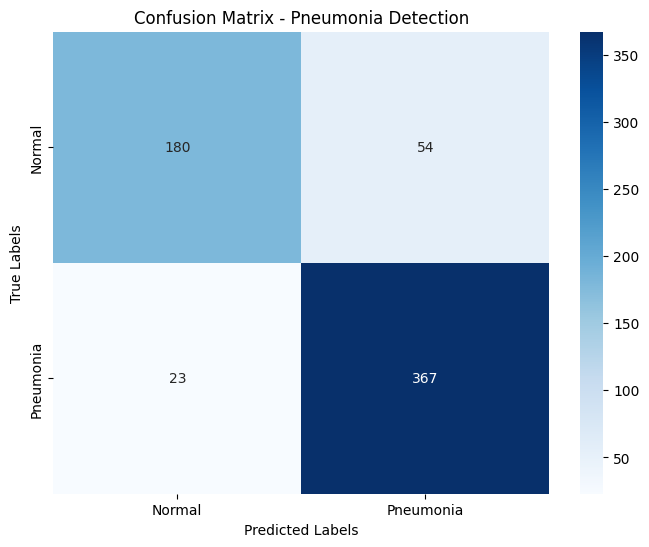


Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.77      0.82       234
   Pneumonia       0.87      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.86       624
weighted avg       0.88      0.88      0.87       624



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Collect all true labels and predictions
y_true = []
y_pred = []

print("Generating predictions for the test set...")
for images, labels in val_dataset:
    # Get predictions (probabilities)
    preds = model.predict(images, verbose=0)

    # Convert probabilities to binary labels (0 or 1)
    # Using 0.5 as threshold (consistent with your manual testing code)
    pred_labels = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()

# 2. Calculate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Pneumonia Detection')
plt.show()

# 4. Print Classification Report for Precision, Recall, and F1-score
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))